<a href="https://colab.research.google.com/github/Nishint0001/DataSci/blob/main/PREDICTING_STOCK_PRICE_USING_SVC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [296]:
# FOR DATA MANIPULATION
import pandas as pd
import numpy as np

#For Machine Learning
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


#TO Plot
import matplotlib.pyplot as plt

#To ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [297]:
df=pd.read_csv("R")
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2022-07-15,2415.000000,2415.000000,2383.100098,2401.800049,2394.590576,4431880
1,2022-07-18,2421.000000,2425.000000,2392.300049,2422.250000,2414.979248,6996757
2,2022-07-19,2400.300049,2447.000000,2400.300049,2437.100098,2429.784668,7587006
3,2022-07-20,2540.000000,2542.500000,2486.250000,2503.000000,2495.486816,11041036
4,2022-07-21,2494.000000,2500.000000,2467.300049,2486.300049,2478.836914,7625468
...,...,...,...,...,...,...,...
242,2023-07-10,2688.899902,2756.000000,2675.000000,2735.050049,2735.050049,15340262
243,2023-07-11,2752.899902,2770.000000,2737.600098,2764.699951,2764.699951,9262001
244,2023-07-12,2766.300049,2802.000000,2761.649902,2767.750000,2767.750000,8645662
245,2023-07-13,2783.899902,2799.000000,2737.250000,2743.000000,2743.000000,6776172


In [298]:
# Changes The Date column as index columns
df.index=pd.to_datetime(df["Date"])


# drop The original date column
df=df.drop(["Date"],axis=1)
df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2022-07-15,2415.000000,2415.000000,2383.100098,2401.800049,2394.590576,4431880
2022-07-18,2421.000000,2425.000000,2392.300049,2422.250000,2414.979248,6996757
2022-07-19,2400.300049,2447.000000,2400.300049,2437.100098,2429.784668,7587006
2022-07-20,2540.000000,2542.500000,2486.250000,2503.000000,2495.486816,11041036
2022-07-21,2494.000000,2500.000000,2467.300049,2486.300049,2478.836914,7625468
...,...,...,...,...,...,...
2023-07-10,2688.899902,2756.000000,2675.000000,2735.050049,2735.050049,15340262
2023-07-11,2752.899902,2770.000000,2737.600098,2764.699951,2764.699951,9262001
2023-07-12,2766.300049,2802.000000,2761.649902,2767.750000,2767.750000,8645662


In [299]:
#CREATING PREDICTOR VARIABLE
df["Open-close"]=df.Open-df.Close

df["High-low"]=df.High-df.Low

df

,Open,High,Low,Close,Adj Close,Volume,Open-close,High-low
Date,,,,,,,,
2022-07-15,2415.000000,2415.000000,2383.100098,2401.800049,2394.590576,4431880,13.199951,31.899902
2022-07-18,2421.000000,2425.000000,2392.300049,2422.250000,2414.979248,6996757,-1.250000,32.699951
2022-07-19,2400.300049,2447.000000,2400.300049,2437.100098,2429.784668,7587006,-36.800049,46.699951
2022-07-20,2540.000000,2542.500000,2486.250000,2503.000000,2495.486816,11041036,37.000000,56.250000
2022-07-21,2494.000000,2500.000000,2467.300049,2486.300049,2478.836914,7625468,7.699951,32.699951
...,...,...,...,...,...,...,...,...
2023-07-10,2688.899902,2756.000000,2675.000000,2735.050049,2735.050049,15340262,-46.150147,81.000000
2023-07-11,2752.899902,2770.000000,2737.600098,2764.699951,2764.699951,9262001,-11.800049,32.399902
2023-07-12,2766.300049,2802.000000,2761.649902,2767.750000,2767.750000,8645662,-1.449951,40.350098


In [300]:
x=df[["Open-close","High-low"]]
x.head()

,Open-close,High-low
Date,,
2022-07-15,13.199951,31.899902
2022-07-18,-1.250000,32.699951
2022-07-19,-36.800049,46.699951
2022-07-20,37.000000,56.250000
2022-07-21,7.699951,32.699951


In [301]:
# Target variables
y = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)
y


array([1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 0, 0])

In [302]:
# MODEL TRAINING

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=33,random_state=35)

In [303]:
x_train

,Open-close,High-low
Date,,
2022-08-04,38.100098,82.750000
2022-08-02,-12.149902,46.250000
2022-08-25,16.899902,40.299804
2023-03-17,21.649902,39.250000
2022-10-21,36.099853,49.800049
...,...,...
2022-09-05,-38.800049,50.500000
2023-04-13,-2.500000,23.800049
2023-06-30,-3.850098,23.199951


In [304]:
cls = SVC().fit(x_train, y_train)
y_pred=cls.predict(x_test)

In [305]:
a_score=accuracy_score(y_pred,y_test)
print(a_score)

0.6666666666666666


In [306]:
df['Predicted_Signal'] = cls.predict(x)
df


,Open,High,Low,Close,Adj Close,Volume,Open-close,High-low,Predicted_Signal
Date,,,,,,,,,
2022-07-15,2415.000000,2415.000000,2383.100098,2401.800049,2394.590576,4431880,13.199951,31.899902,0
2022-07-18,2421.000000,2425.000000,2392.300049,2422.250000,2414.979248,6996757,-1.250000,32.699951,0
2022-07-19,2400.300049,2447.000000,2400.300049,2437.100098,2429.784668,7587006,-36.800049,46.699951,1
2022-07-20,2540.000000,2542.500000,2486.250000,2503.000000,2495.486816,11041036,37.000000,56.250000,0
2022-07-21,2494.000000,2500.000000,2467.300049,2486.300049,2478.836914,7625468,7.699951,32.699951,0
...,...,...,...,...,...,...,...,...,...
2023-07-10,2688.899902,2756.000000,2675.000000,2735.050049,2735.050049,15340262,-46.150147,81.000000,1
2023-07-11,2752.899902,2770.000000,2737.600098,2764.699951,2764.699951,9262001,-11.800049,32.399902,0
2023-07-12,2766.300049,2802.000000,2761.649902,2767.750000,2767.750000,8645662,-1.449951,40.350098,0


In [307]:
# Calculate daily returns
df['Return'] = df.Close.pct_change()


In [308]:
# Calculate strategy returns
df['Strategy_Return'] = df.Return *df.Predicted_Signal.shift(1)


In [309]:
# Calculate Cumulutive returns
df['Cum_Ret'] = df['Return'].cumsum()
df


,Open,High,Low,Close,Adj Close,Volume,Open-close,High-low,Predicted_Signal,Return,Strategy_Return,Cum_Ret
Date,,,,,,,,,,,,
2022-07-15,2415.000000,2415.000000,2383.100098,2401.800049,2394.590576,4431880,13.199951,31.899902,0,NaN,NaN,NaN
2022-07-18,2421.000000,2425.000000,2392.300049,2422.250000,2414.979248,6996757,-1.250000,32.699951,0,0.008514,0.000000,0.008514
2022-07-19,2400.300049,2447.000000,2400.300049,2437.100098,2429.784668,7587006,-36.800049,46.699951,1,0.006131,0.000000,0.014645
2022-07-20,2540.000000,2542.500000,2486.250000,2503.000000,2495.486816,11041036,37.000000,56.250000,0,0.027040,0.027040,0.041685
2022-07-21,2494.000000,2500.000000,2467.300049,2486.300049,2478.836914,7625468,7.699951,32.699951,0,-0.006672,-0.000000,0.035013
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-07-10,2688.899902,2756.000000,2675.000000,2735.050049,2735.050049,15340262,-46.150147,81.000000,1,0.038521,0.000000,0.148874
2023-07-11,2752.899902,2770.000000,2737.600098,2764.699951,2764.699951,9262001,-11.800049,32.399902,0,0.010841,0.010841,0.159714
2023-07-12,2766.300049,2802.000000,2761.649902,2767.750000,2767.750000,8645662,-1.449951,40.350098,0,0.001103,0.000000,0.160818


In [310]:
# Plot Strategy Cumulative returns
df['Cum_Strategy'] = df['Strategy_Return'].cumsum()
df



,Open,High,Low,Close,Adj Close,Volume,Open-close,High-low,Predicted_Signal,Return,Strategy_Return,Cum_Ret,Cum_Strategy
Date,,,,,,,,,,,,,
2022-07-15,2415.000000,2415.000000,2383.100098,2401.800049,2394.590576,4431880,13.199951,31.899902,0,NaN,NaN,NaN,NaN
2022-07-18,2421.000000,2425.000000,2392.300049,2422.250000,2414.979248,6996757,-1.250000,32.699951,0,0.008514,0.000000,0.008514,0.000000
2022-07-19,2400.300049,2447.000000,2400.300049,2437.100098,2429.784668,7587006,-36.800049,46.699951,1,0.006131,0.000000,0.014645,0.000000
2022-07-20,2540.000000,2542.500000,2486.250000,2503.000000,2495.486816,11041036,37.000000,56.250000,0,0.027040,0.027040,0.041685,0.027040
2022-07-21,2494.000000,2500.000000,2467.300049,2486.300049,2478.836914,7625468,7.699951,32.699951,0,-0.006672,-0.000000,0.035013,0.027040
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-07-10,2688.899902,2756.000000,2675.000000,2735.050049,2735.050049,15340262,-46.150147,81.000000,1,0.038521,0.000000,0.148874,0.202588
2023-07-11,2752.899902,2770.000000,2737.600098,2764.699951,2764.699951,9262001,-11.800049,32.399902,0,0.010841,0.010841,0.159714,0.213428
2023-07-12,2766.300049,2802.000000,2761.649902,2767.750000,2767.750000,8645662,-1.449951,40.350098,0,0.001103,0.000000,0.160818,0.213428


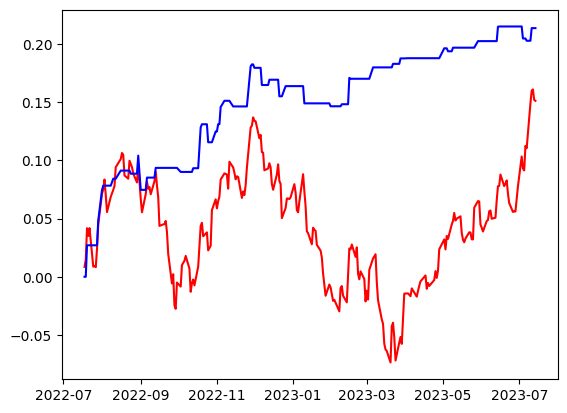

In [311]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(df['Cum_Ret'],color='red')
plt.plot(df['Cum_Strategy'],color='blue')
